<a href="https://colab.research.google.com/github/SaboorBandhani/Data-Science-Project/blob/main/Customer_Churn_Prediction_Datascience_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**STEP 1: PROBLEM SELECTION & DATASET**
**Project Title:** Customer Churn Prediction & Analysis

**Problem Type:** Classification (Predicting if a customer will leave: Yes or No)

**Dataset:** Telco Customer Churn Dataset

**Objective:** To identify patterns in customer behavior and predict churn using Machine Learning.

**STEP 2: DATA COLLECTION & INITIAL INSPECTION**

In this step, we load the data and look at it from all angles using basic inspection commands.

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv('Telco-Customer-Churn.csv')

FileNotFoundError: [Errno 2] No such file or directory: 'Telco-Customer-Churn.csv'

In [ ]:
# 1. See the first 5 rows
print("--- First 5 Rows ---")
df.head()

--- First 5 Rows ---


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
# 2. See the last 5 rows (as in your car_data example)
print("\n--- Last 5 Rows ---")
df.tail()


--- Last 5 Rows ---


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [ ]:
# 3. Check Data Types
print("\n--- Data Types of all Columns ---")
df.dtypes


--- Data Types of all Columns ---


,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [ ]:
# 4. Check detailed info
print("\n--- Dataset Info ---")
df.info()


--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  70

In [ ]:
# 5. Check Unique values in 'PaymentMethod'
print("\n--- Unique values in PaymentMethod ---")
print(df['PaymentMethod'].unique())


--- Unique values in PaymentMethod ---
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']


In [ ]:
# 6. Check how many unique values in 'PaymentMethod'
print("\n--- Number of unique values in PaymentMethod ---")
print(df['PaymentMethod'].nunique())


--- Number of unique values in PaymentMethod ---
4


**STEP 3: DATA EXPLORATION (Grouping, Filtering, and Math)**

Now we will explore the data using the specific techniques(groupby, str.contains, etc.).

In [ ]:
# 1. Approach 1: Filtering customers who have 'Fiber optic' internet
fiber_data = df[df['InternetService'] == 'Fiber optic']
print("--- Customers with Fiber Optic (Filtering) ---")
fiber_data.head()

--- Customers with Fiber Optic (Filtering) ---


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
12,8091-TTVAX,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,No,Credit card (automatic),100.35,5681.1,No


In [ ]:
# 2. Approach 2: Using GroupBy to get the same group (As in your Weather example)
fiber_group = df.groupby('InternetService').get_group('Fiber optic')
print("\n--- Customers with Fiber Optic (GroupBy) ---")
fiber_group.head()


--- Customers with Fiber Optic (GroupBy) ---


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
12,8091-TTVAX,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,No,Credit card (automatic),100.35,5681.1,No


In [ ]:
# 3. Using str.contains to find customers whose PaymentMethod contains the word 'check'
# This is useful when a category has multiple variations
check_payment_df = df[df['PaymentMethod'].str.contains('check')]
print("\n--- Customers using Check as Payment ---")
check_payment_df['PaymentMethod'].value_counts()


--- Customers using Check as Payment ---


,count
PaymentMethod,
Electronic check,2365
Mailed check,1612


In [ ]:
# 4. Calculating Mean and Standard Deviation (As in your Weather example)
avg_monthly_charge = df['MonthlyCharges'].mean()
std_monthly_charge = df['MonthlyCharges'].std()

In [ ]:
print(f"Mean of Monthly Charges: {avg_monthly_charge}")
print(f"Standard Deviation of Monthly Charges: {std_monthly_charge}")

Mean of Monthly Charges: 64.76169246059918
Standard Deviation of Monthly Charges: 30.09004709767854


In [ ]:
# 5. Renaming Columns using inplace=True
df.rename(columns={ "tenure" : "Tenure_Months" }, inplace=True)
df.rename(columns={ "MonthlyCharges" : "Monthly_Bill" }, inplace=True)

In [ ]:
print("\n--- Columns after Renaming ---")
df.columns


--- Columns after Renaming ---


Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'Tenure_Months', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'Monthly_Bill', 'TotalCharges', 'Churn'],
      dtype='object')

**STEP 4: DATA PREPROCESSING (Handling Nulls & Outliers)**

We will check for nulls, convert data types, and use the ~ (NOT) operator to filter data

In [ ]:
# 1. Checking for Null Values (Standard Check)
print("--- Checking for Standard Null Values ---")
print(df.isnull().sum())

--- Checking for Standard Null Values ---
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
Tenure_Months       0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
Monthly_Bill        0
TotalCharges        0
Churn               0
dtype: int64


In [ ]:
# 2. Deep Dive: 'TotalCharges' is text but should be numeric
# We convert it and check for hidden nulls
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [ ]:
print("\n--- Null Values found after Numeric Conversion ---")
print(df.isnull().sum())


--- Null Values found after Numeric Conversion ---
customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
Tenure_Months        0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
Monthly_Bill         0
TotalCharges        11
Churn                0
dtype: int64


In [ ]:
# 3. Handling Nulls: We will fill them with the Mean (To keep data size intact)
mean_val = df['TotalCharges'].mean()
df['TotalCharges'].fillna(mean_val, inplace=True)

print("\n--- Null Values after filling with Mean ---")
print(df.isnull().sum())


--- Null Values after filling with Mean ---
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
Tenure_Months       0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
Monthly_Bill        0
TotalCharges        0
Churn               0
dtype: int64


/tmp/ipykernel_5743/430841815.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(mean_val, inplace=True)


In [ ]:
# 4. Using the NOT (~) Operator to filter out specific rows
# Example: We want to see data where Monthly_Bill is NOT greater than 100
low_bill_df = df[~(df['Monthly_Bill'] > 100)]
print(f"\nOriginal Data Shape: {df.shape}")
print(f"Filtered Data Shape (Bills <= 100): {low_bill_df.shape}")


Original Data Shape: (7043, 21)
Filtered Data Shape (Bills <= 100): (6141, 21)


In [ ]:
# 5. Dropping irrelevant column
df.drop(columns=['customerID'], inplace=True)

In [ ]:
# --- BASIC OUTLIER REMOVAL ---
print("Data size before outlier removal:", df.shape)

# Find the 99th percentile for the Monthly Bill
highest_bill = df['Monthly_Bill'].quantile(0.99)
print(highest_bill)
# Keep only the rows where the bill is less than or equal to that number
df = df[df['Monthly_Bill'] <= highest_bill]

print("Data size after outlier removal:", df.shape)

Data size before outlier removal: (7043, 20)
114.729
Data size after outlier removal: (6972, 20)


**STEP 5: FEATURE ENGINEERING**

In [ ]:
# Let's create a feature that calculates the average bill manually
# We add 1 to Tenure_Months to avoid a "division by zero" error for brand-new customers
df['Calculated_Avg_Bill'] = df['TotalCharges'] / (df['Tenure_Months'] + 1)

print("\n--- New Feature Created ---")
print(df[['Tenure_Months', 'TotalCharges', 'Calculated_Avg_Bill']].head())


--- New Feature Created ---
   Tenure_Months  TotalCharges  Calculated_Avg_Bill
0              1         29.85            14.925000
1             34       1889.50            53.985714
2              2        108.15            36.050000
3             45       1840.75            40.016304
4              2        151.65            50.550000


In [ ]:
# --- CORRELATION CHECK ---
# Select only our main numerical columns
numerical_data = df[['Tenure_Months', 'Monthly_Bill', 'Calculated_Avg_Bill']]

print("\n--- Correlation Matrix ---")
# This will print a simple table showing how these features correlate (from -1.0 to 1.0)
print(numerical_data.corr())


--- Correlation Matrix ---
                     Tenure_Months  Monthly_Bill  Calculated_Avg_Bill
Tenure_Months             1.000000      0.229395             0.078658
Monthly_Bill              0.229395      1.000000             0.279531
Calculated_Avg_Bill       0.078658      0.279531             1.000000


**STEP 6: EXPLORATORY DATA ANALYSIS (EDA)**

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

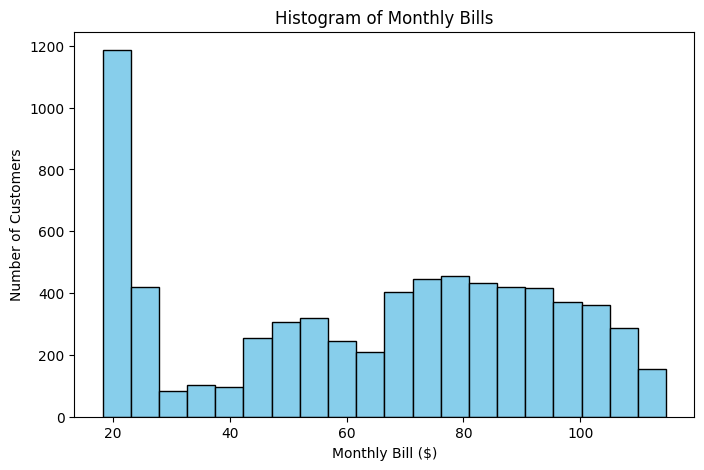

In [ ]:
# --- BASIC EDA UPGRADE ---
# 1. Histogram (To see the distribution of bills)
plt.figure(figsize=(8,5))
plt.hist(df['Monthly_Bill'], bins=20, color='skyblue', edgecolor='black')
plt.title("Histogram of Monthly Bills")
plt.xlabel("Monthly Bill ($)")
plt.ylabel("Number of Customers")
plt.show()

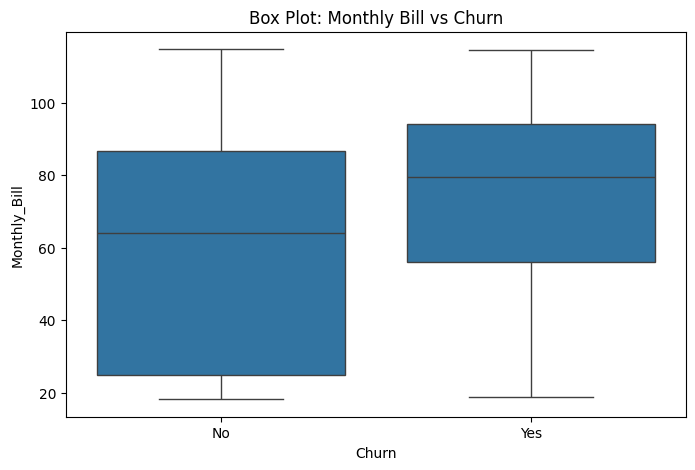

In [ ]:
# 2. Box Plot (To see if churned customers had higher bills)
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn', y='Monthly_Bill', data=df)
plt.title("Box Plot: Monthly Bill vs Churn")
plt.show()

/tmp/ipykernel_5743/3262983339.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette='magma')


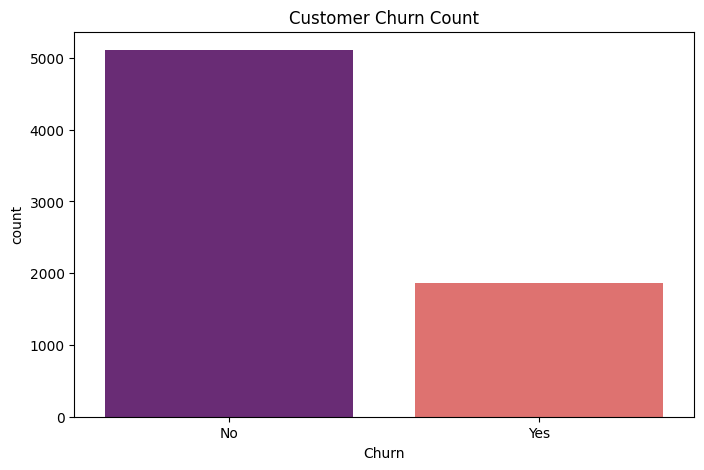

In [ ]:
# 3. Distribution of Churn (Count plot)
plt.figure(figsize=(8,5))
sns.countplot(x='Churn', data=df, palette='magma')
plt.title("Customer Churn Count")
plt.show()

**STEP 7: MODEL BUILDING (Preparation & Training)**

We will use pd.get_dummies for encoding

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

In [ ]:
# 1. Encode categorical variables (pd.get_dummies)
df_encoded = pd.get_dummies(df, drop_first=True)

# 2. Split Features and Target
# In our encoded data, 'Churn_Yes' is the target column
X = df_encoded.drop("Churn_Yes", axis=1)
y = df_encoded["Churn_Yes"]

In [ ]:
# 3. Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# 4. Scale features (Important for models)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# 5. Train Model: Logistic Regression
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [ ]:
# 6. Train Model: Random Forest
rf_model = RandomForestClassifier(n_estimators=100)
rf_model.fit(X_train, y_train)

print("\nModels trained successfully!")


Models trained successfully!


**STEP 8: MODEL EVALUATION**

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix

In [ ]:
# Predictions
predictions = model.predict(X_test)
rf_predictions = rf_model.predict(X_test)

In [ ]:
# Accuracy Score
print("Logistic Regression Accuracy:", accuracy_score(y_test, predictions))
print("Random Forest Accuracy:", accuracy_score(y_test, rf_predictions))

Logistic Regression Accuracy: 0.792831541218638
Random Forest Accuracy: 0.7906810035842294


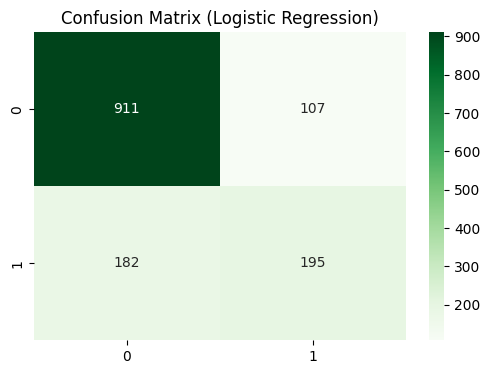

In [ ]:
# Confusion Matrix for Logistic Regression
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, predictions), annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix (Logistic Regression)")
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print("\n--- Logistic Regression Report ---")
print(classification_report(y_test, predictions))

print("\n--- Random Forest Report ---")
print(classification_report(y_test, rf_predictions))


--- Logistic Regression Report ---
              precision    recall  f1-score   support

       False       0.83      0.89      0.86      1018
        True       0.65      0.52      0.57       377

    accuracy                           0.79      1395
   macro avg       0.74      0.71      0.72      1395
weighted avg       0.78      0.79      0.79      1395


--- Random Forest Report ---
              precision    recall  f1-score   support

       False       0.83      0.90      0.86      1018
        True       0.65      0.50      0.56       377

    accuracy                           0.79      1395
   macro avg       0.74      0.70      0.71      1395
weighted avg       0.78      0.79      0.78      1395



In [ ]:
pip install gradio

In [ ]:
import gradio as gr
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- 1. Save STATIC EDA Plots (Dataset Overview) ---
plt.figure(figsize=(6,4))
sns.boxplot(x='Churn', y='Monthly_Bill', data=df)
plt.title("Box Plot: Monthly Bill vs Churn")
plt.tight_layout()
plt.savefig('boxplot.png')
plt.close()

plt.figure(figsize=(6,4))
plt.hist(df['Monthly_Bill'], bins=20, color='skyblue', edgecolor='black')
plt.title("Distribution of Monthly Bills")
plt.xlabel("Monthly Bill ($)")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.savefig('histogram.png')
plt.close()

# --- 2. Define the prediction function (DYNAMIC Plots) ---
def predict_churn(row_index):
    try:
        idx = int(row_index)
        customer_data = X_test[idx].reshape(1, -1)

        # --- Random Forest ---
        rf_prediction = rf_model.predict(customer_data)[0]
        rf_probabilities = rf_model.predict_proba(customer_data)[0]
        rf_result = "⚠️ Predicted to CHURN." if rf_prediction == 1 else "✅ Predicted to STAY."

        # --- Logistic Regression ---
        lr_prediction = model.predict(customer_data)[0]
        lr_probabilities = model.predict_proba(customer_data)[0]
        lr_result = "⚠️ Predicted to CHURN." if lr_prediction == 1 else "✅ Predicted to STAY."

        # --- Create Dynamic Graph 1: RF Confidence ---
        plt.figure(figsize=(5,4))
        plt.bar(['No (0)', 'Yes (1)'], rf_probabilities, color=['#2ca02c', '#d62728'])
        plt.title(f"Random Forest Confidence (ID: {idx})")
        plt.ylabel("Probability")
        plt.ylim(0, 1)
        plt.tight_layout()
        plt.savefig('rf_dynamic.png')
        plt.close()

        # --- Create Dynamic Graph 2: LR Confidence ---
        plt.figure(figsize=(5,4))
        plt.bar(['Stay (0)', 'Churn (1)'], lr_probabilities, color=['#2ca02c', '#d62728'])
        plt.title(f"Logistic Regression Confidence (ID: {idx})")
        plt.ylabel("Probability")
        plt.ylim(0, 1)
        plt.tight_layout()
        plt.savefig('lr_dynamic.png')
        plt.close()

        # Return ONLY the dynamic elements
        return rf_result, lr_result, 'rf_dynamic.png', 'lr_dynamic.png'

    except Exception as e:
        return "Error: Invalid ID", "Error: Invalid ID", None, None

# --- 3. Create the Gradio UI using Blocks ---
with gr.Blocks(theme="default") as interface:
    gr.Markdown("# 📊 Customer Churn Predictor Dashboard")

    # === SECTION A: INDIVIDUAL ANALYSIS (Dynamic) ===
    gr.Markdown("### 👤 Individual Customer Analysis")
    with gr.Row():
        with gr.Column():
            user_input = gr.Number(label=f"Enter Customer ID (Row Index 0 to {len(X_test)-1})")
            submit_btn = gr.Button("Predict Churn", variant="primary")

        with gr.Column():
            rf_output = gr.Textbox(label="🌲 Random Forest Prediction")
            lr_output = gr.Textbox(label="📈 Logistic Regression Prediction")

    with gr.Row():
        dynamic_image_1 = gr.Image(label="Random Forest Confidence")
        dynamic_image_2 = gr.Image(label="Logistic Regression Confidence")

    gr.Markdown("---") # Adds a nice horizontal dividing line

    # === SECTION B: DATASET OVERVIEW (Static) ===
    gr.Markdown("### 🌍 Overall Dataset Overview")
    with gr.Row():
        # We load the static images directly into the UI components here
        static_image_1 = gr.Image(value="boxplot.png", label="Monthly Bill vs Churn (Whole Dataset)", interactive=False)
        static_image_2 = gr.Image(value="histogram.png", label="Distribution of Monthly Bills", interactive=False)

    # Connect the button (Only updates the dynamic outputs in Section A)
    submit_btn.click(
        fn=predict_churn,
        inputs=user_input,
        outputs=[rf_output, lr_output, dynamic_image_1, dynamic_image_2]
    )

# --- 4. Launch the app ---
interface.launch(share=True)

NameError: name 'df' is not defined

<Figure size 600x400 with 0 Axes>